['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
Name: Drug, dtype: object
DecisionTrees's Accuracy:  0.9833333333333333


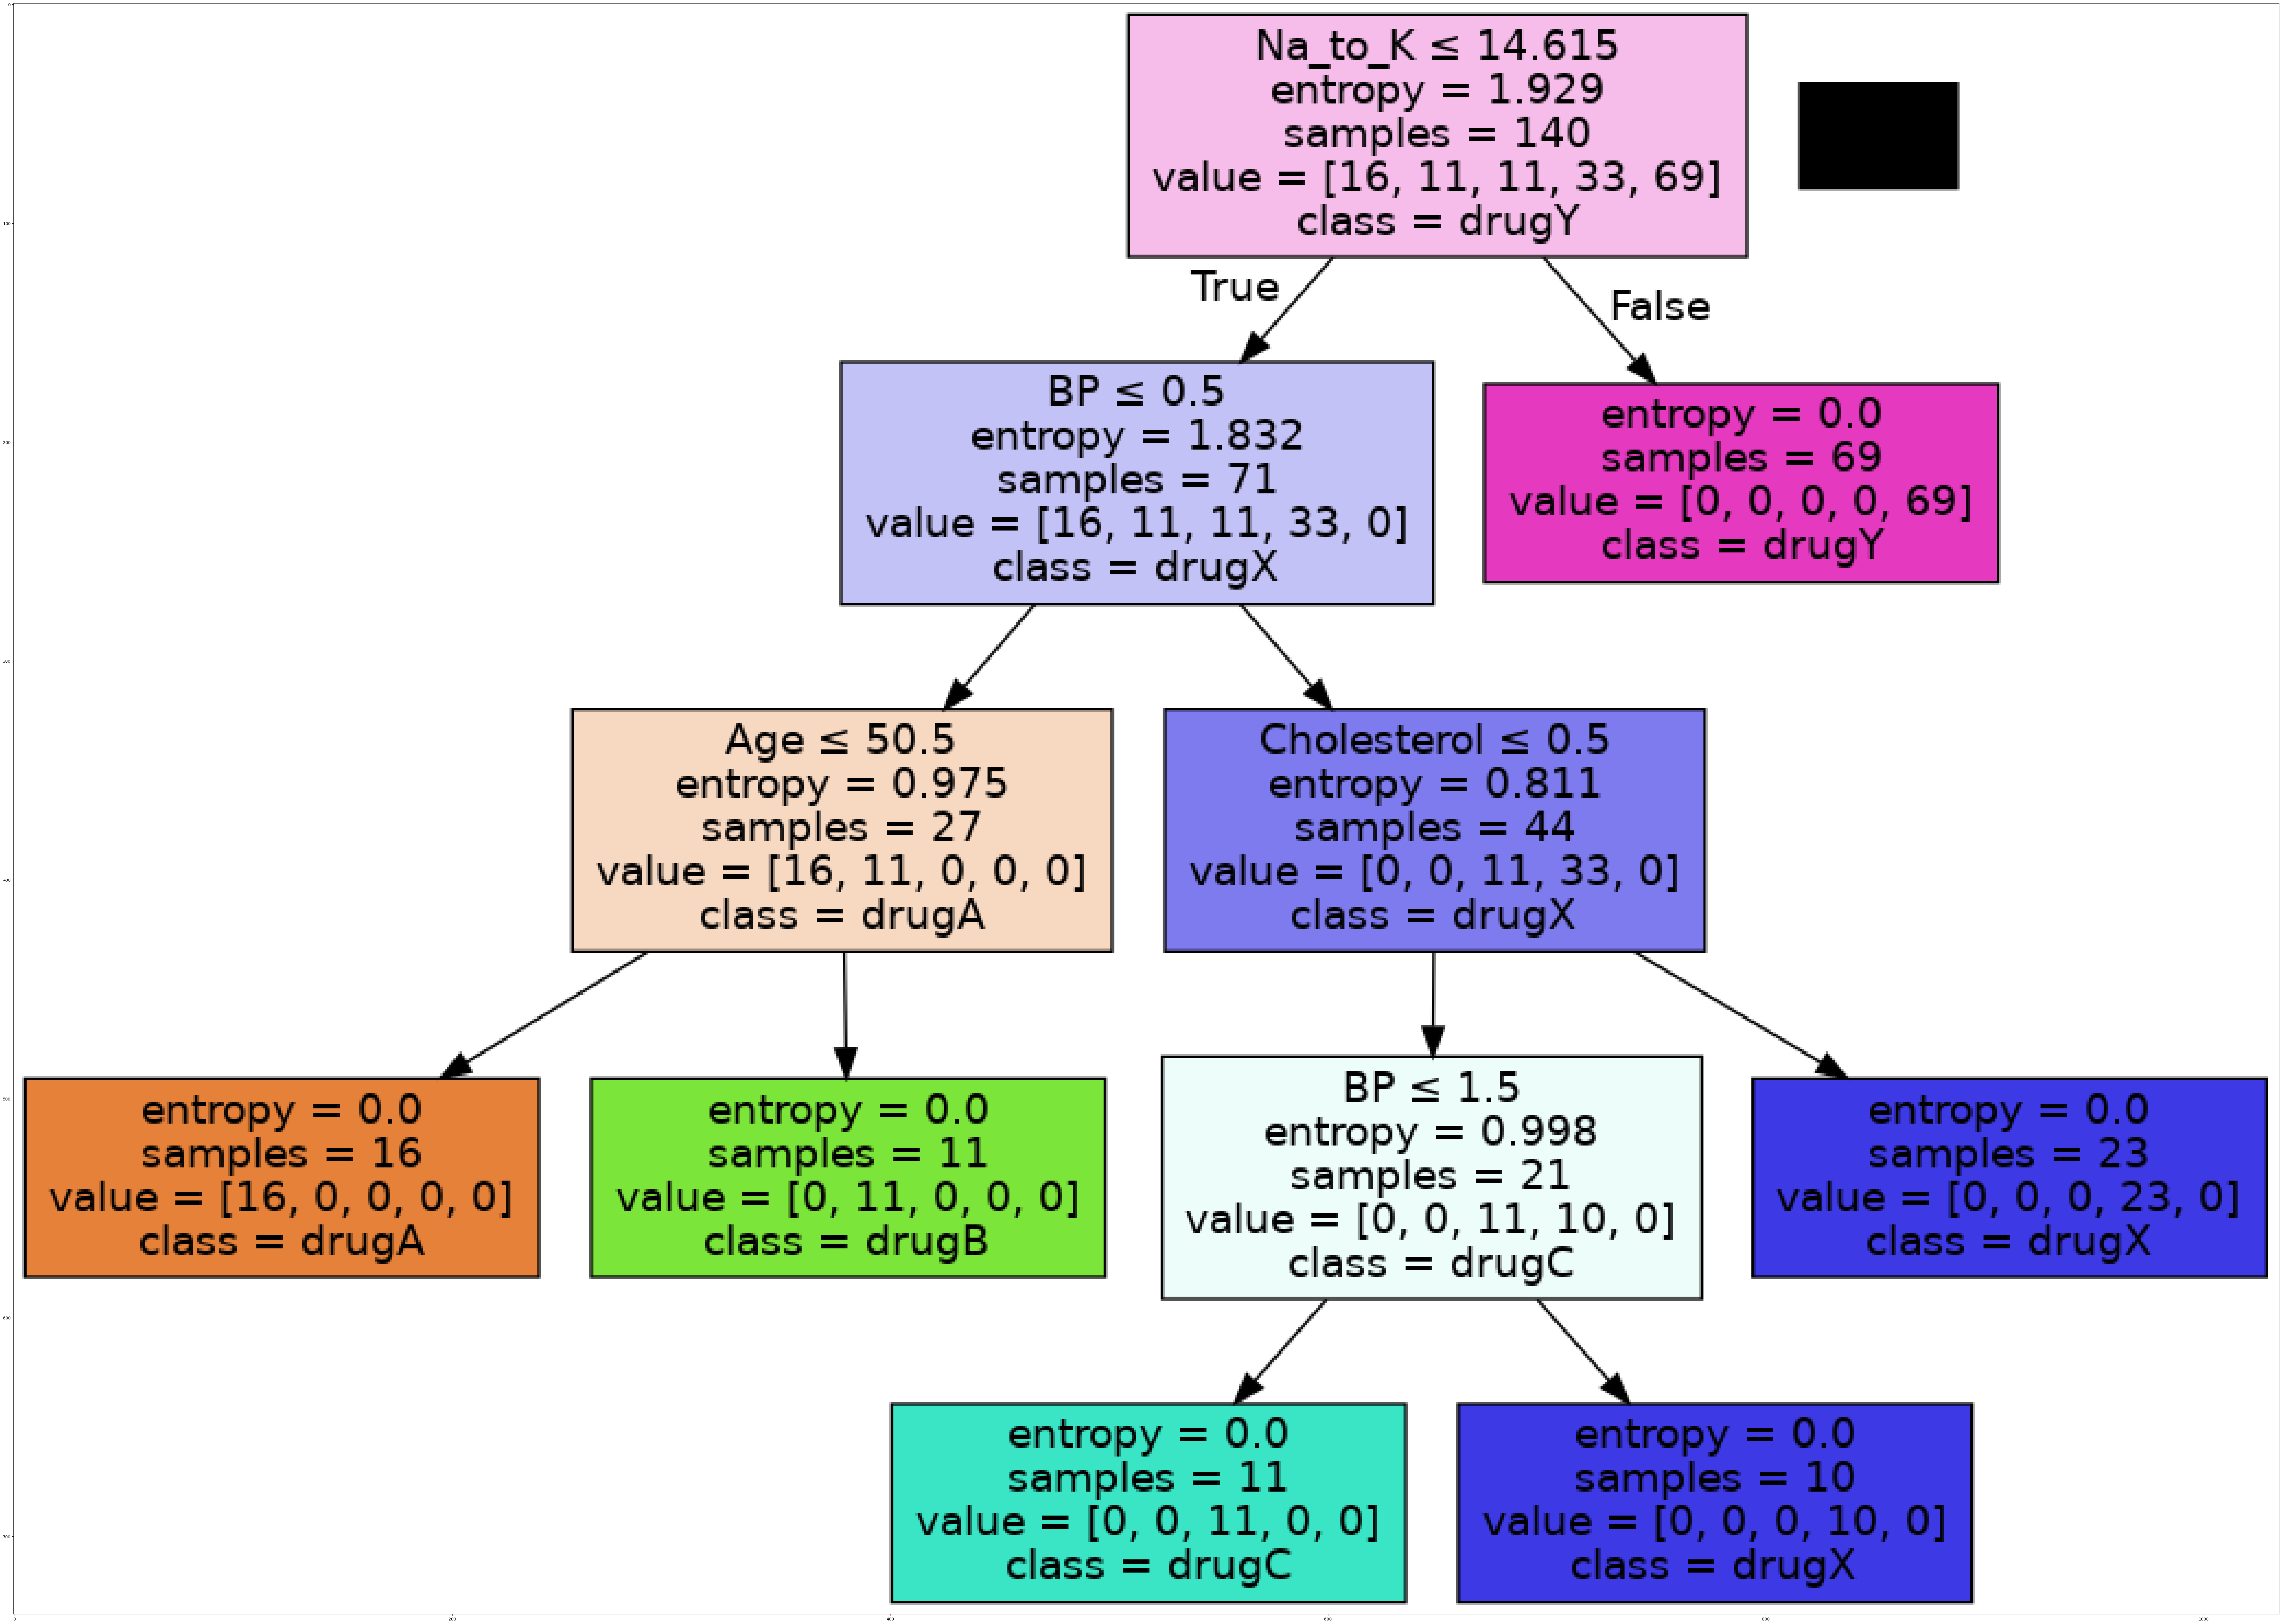

In [1]:
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

my_data = pd.read_csv("/home/jupyter/work/data/drug200.csv", delimiter=",")
my_data[0:5]

X = my_data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]

from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

X[0:5]

y = my_data["Drug"]
y[0:5]

from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=3)

print("X_trainset shape:", X_trainset.shape)
print("y_trainset shape:", y_trainset.shape)
print("Train sizes match:", X_trainset.shape[0] == y_trainset.shape[0])

print("X_testset shape:", X_testset.shape)
print("y_testset shape:", y_testset.shape)
print("Test sizes match:", X_testset.shape[0] == y_testset.shape[0])

drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
drugTree

drugTree.fit(X_trainset,y_trainset)

predTree = drugTree.predict(X_testset)
print (predTree [0:5])
print (y_testset [0:5])

from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

from six import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
%matplotlib inline

dot_data = StringIO()
filename = "drugtree.png"
featureNames = my_data.columns[0:5]
targetNames = my_data["Drug"].unique().tolist()
out=tree.export_graphviz(drugTree,feature_names=featureNames, out_file=dot_data, 
                         class_names= np.unique(y_trainset), filled=True,  
                         special_characters=True,rotate=False)  
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png(filename)
img = mpimg.imread(filename)
plt.figure(figsize=(100, 200))
plt.imshow(img,interpolation='nearest')